# Reviewer 1 comment 1

Reviewer comment copy-pasted:
> The paper reports greedy forward feature selection with 10 times cross-validation and claims an improvement from MSE >22,000 to 3.87 using 12 selected wavelengths. That is promising, but the manuscript does not clearly state whether feature selection was performed inside each training fold or on the full dataset before cross-validation. Please clarify this for the readers.

Relevant sections from the paper:
> Using food dye dilutions as a model system, the mean squared error was reduced from over 22,000 with a single wavelength to 3.87 using twelve selected features, corresponding to a more than 5,700-fold enhancement. (page 1 abstract)
> Table 1 lists the ordered sequence of wavelengths added during the feature selection process, along with the corresponding mean squared error (MSE), root mean squared error (RMSE), and the relative improvement in both metrics compared to the single-wavelength baseline. The first row establishes the baseline case, where only the best-performing single wavelength (457.275 nm) is used, yielding an RMSE of 148.85. As additional wavelengths are incorporated, both MSE and RMSE drop sharply, especially within the first 3 to 5 additions. Notably, by the time twelve features have been selected, the MSE drops to 3.87 and RMSE to just 1.97. This represents a staggering 5725-fold improvement in MSE and over 75-fold improvement in RMSE just by using 12 wavelengths rather than just one wavelength (the best performing wavelength).  (page 10 3.2 multiwave modeling)

Tasks:
- Identify the code needed to produce the results for Table 1
- Identify when the feature selection was performed
  - 1. in each training fold
  - 2. full dataset before cross-validation

In [18]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from whecho.whecho import whecho_simple

Step 1: added wv_457_275 -> 10-fold MSE: 22157.58
Step 2: added wv_427_16 -> 10-fold MSE: 6753.58
Step 3: added wv_631_853 -> 10-fold MSE: 6861.90
Step 4: added wv_423_564 -> 10-fold MSE: 4697.08
Step 5: added wv_478_19 -> 10-fold MSE: 3205.72
Step 6: added wv_479_65 -> 10-fold MSE: 2388.56
Step 7: added wv_545_117 -> 10-fold MSE: 1975.39
Step 8: added wv_629_068 -> 10-fold MSE: 3017.36
Step 9: added wv_452_447 -> 10-fold MSE: 2759.62
Step 10: added wv_547_774 -> 10-fold MSE: 8.81
Step 11: added wv_631_058 -> 10-fold MSE: 18.37
Step 12: added wv_488_603 -> 10-fold MSE: 3.87
Step 13: added wv_455_176 -> 10-fold MSE: 32.14
Step 14: added wv_633_841 -> 10-fold MSE: 70.15
Step 15: added wv_633_046 -> 10-fold MSE: 29.79
Step 16: added wv_635_827 -> 10-fold MSE: 72.23
Step 17: added wv_421_447 -> 10-fold MSE: 115.99
Step 18: added wv_419_329 -> 10-fold MSE: 166.32
Step 19: added wv_417_21 -> 10-fold MSE: 213.04
Step 20: added wv_415_089 -> 10-fold MSE: 295.73


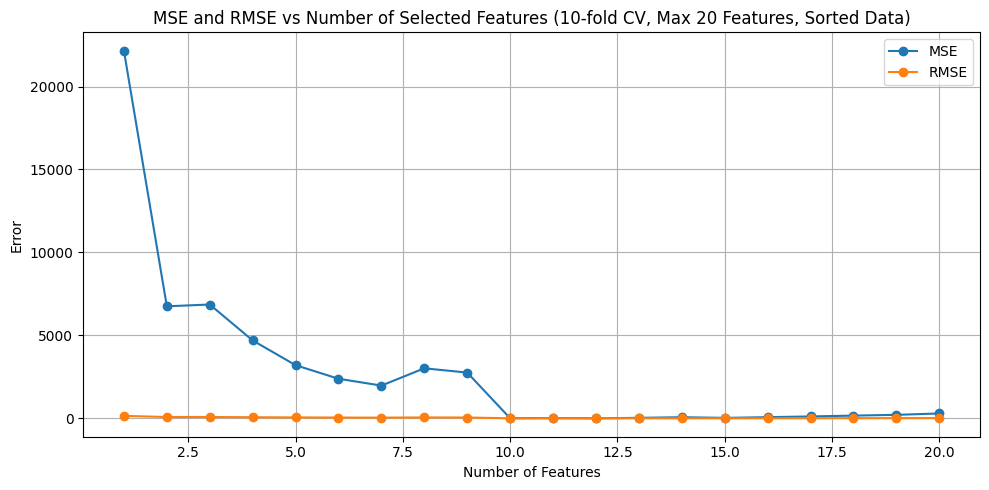

In [16]:
# === Load preprocessed sorted data ===
df = pd.read_csv("..\..\p11_new_paper_test\ML_colorimetric_data\ML colorimetric data\processed_sorted_transmission.csv", index_col=0)

# === Prepare X and y ===
X = df.copy()
y = X.index.values
X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

# === Define 10-fold CV MSE ===
def kfold_cv_mse(X_vals, y_vals, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_vals = []
    for train_idx, val_idx in kf.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
    return np.mean(mse_vals)

# === Greedy feature selection with a 20-feature cap ===
remaining = list(X.columns)
selected = []
data_list = []

best_mse = float("inf")
max_features = 20  # Limit number of added features

for i in range(1, max_features + 1):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected + [candidate]
        mse = kfold_cv_mse(X[test_features].values, y)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_candidate = candidate

    if best_candidate is None:
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list.append({
        "n_feats": len(selected),
        "features": selected.copy(),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse)
    })

    print(f"Step {len(selected)}: added {best_candidate} -> 10-fold MSE: {best_mse:.2f}")

# === Convert to DataFrame and Plot ===
results_df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 5))
plt.plot(results_df["n_feats"], results_df["mse"], label="MSE", marker="o")
plt.plot(results_df["n_feats"], results_df["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, Max 20 Features, Sorted Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Ok, so the feature selection was actually performed based on the MSE of the holdout points from the 10-fold cross validation.

I have added explicitly what was performed to the main text.

For an effective response to the reviewer we must also demonstrate that this technique is robust to training data leakage.

To get around this, we can perform a nested cross-validation approach were we repeat this process on already cross-validated folds and report both the standard MSE that we reported in our main text and the hold-out MSE across all the hold out points from the outer cross-validated folds.

In [3]:
from tqdm.autonotebook import tqdm

C:\Users\craut\AppData\Local\Temp\ipykernel_4916\987820437.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
# first check if the result csv is already saved
if os.path.exists("loo_index_holdout_results.csv"):
    loo_index_ho_results_df = pd.read_csv("loo_index_holdout_results.csv")
    # now exit out of this cell since we already have the results
    raise SystemExit("Results already loaded from CSV, skipping LOO CV computation.")


X = df.copy()
y = X.index.values
X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

kf = KFold(n_splits=len(y), shuffle=True, random_state=42)

loo_index_ho_results = []

loo_idx = 0
for train_idx, val_idx in tqdm(kf.split(X), total=len(y), desc="Outer LOO CV"):
    X_tr, X_holdout = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_holdout = y[train_idx], y[val_idx]

    # now we perform the greedy feature selection using only the training data
    # === Greedy feature selection with a 20-feature cap ===
    remaining = list(X_tr.columns)
    selected = []
    data_list = []

    best_mse = float("inf")
    max_features = 20  # Limit number of added features

    for i in range(1, max_features + 1):
        best_mse_this_round = float("inf")
        best_candidate = None

        for candidate in remaining:
            test_features = selected + [candidate]
            mse = kfold_cv_mse(X_tr[test_features].values, y_tr)
            if mse < best_mse_this_round:
                best_mse_this_round = mse
                best_candidate = candidate

        if best_candidate is None:
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        best_mse = best_mse_this_round
        data_list.append({
            "n_feats": len(selected),
            "features": selected.copy(),
            "mse": best_mse,
            "rmse": np.sqrt(best_mse),
            "ho_se": mean_squared_error(y_holdout, LinearRegression().fit(X_tr[selected].values, y_tr).predict(X_holdout[selected].values)),
            "loo_index": loo_idx
        })


    # === Convert to DataFrame and Plot ===
    results_df = pd.DataFrame(data_list)
    loo_index_ho_results.append(results_df)
    loo_idx += 1
loo_index_ho_results_df = pd.concat(loo_index_ho_results, ignore_index=True)

SystemExit: Results already loaded from CSV, skipping LOO CV computation.

c:\Users\craut\.virtualenvs\colorimetry_ML-6CtRR2jE\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# save the loo_index_ho_results_df for later analysis
loo_index_ho_results_df.to_csv("loo_index_holdout_results.csv", index=False)

In [5]:
loo_index_ho_results_df

,n_feats,features,mse,rmse,ho_se,loo_index
0,1,['wv_460_839'],21056.031549,145.106966,54700.523448,0
1,2,"['wv_460_839', 'wv_427_16']",6380.035134,79.875122,37486.347387,0
2,3,"['wv_460_839', 'wv_427_16', 'wv_428_639']",4442.538579,66.652371,40494.481668,0
3,4,"['wv_460_839', 'wv_427_16', 'wv_428_639', 'wv_...",4517.102434,67.209392,39999.780108,0
4,5,"['wv_460_839', 'wv_427_16', 'wv_428_639', 'wv_...",4408.296310,66.395002,31643.918994,0
...,...,...,...,...,...,...
255,16,"['wv_457_275', 'wv_427_16', 'wv_494_836', 'wv_...",548.638972,23.423044,9792.018663,12
256,17,"['wv_457_275', 'wv_427_16', 'wv_494_836', 'wv_...",570.958916,23.894747,10180.242061,12
257,18,"['wv_457_275', 'wv_427_16', 'wv_494_836', 'wv_...",611.104936,24.720537,12930.915718,12
258,19,"['wv_457_275', 'wv_427_16', 'wv_494_836', 'wv_...",603.688137,24.570066,13939.168937,12


In [7]:
loo_index_ho_results_df[~loo_index_ho_results_df.loo_index.isin({0,12})].groupby("n_feats")[["ho_se","mse"]].mean()

,ho_se,mse
n_feats,,
1,2.626654e+04,23159.749595
2,2.015423e+04,9273.712005
3,3.064760e+04,7984.881263
4,3.627241e+04,7340.266300
5,4.713912e+04,5510.047983
6,5.984640e+04,5098.997796
7,3.859898e+05,4216.359916
8,6.848784e+05,2915.616258
9,7.220426e+05,7905.803460


In [ ]:
# redo the previous work, but force the endpoints to be part of the training data always to ensure no out of LOD behaviours
if os.path.exists("loo_index_ho_results_enpts_forced_in_tr.csv"):
    loo_index_ho_results_enpts_forced_in_tr_df = pd.read_csv("loo_index_holdout_results_enpts_forced_in_tr.csv")
    # now exit out of this cell since we already have the results
    raise SystemExit("Results already loaded from CSV, skipping LOO CV computation with endpoints forced in training data.")

endpts = [df.index.values[0], df.index.values[-1]]

df_enpts_only = df[df.index.isin(endpts)].copy(deep=True)
df_no_endpts = df[~df.index.isin(endpts)].copy(deep=True)

X = df_no_endpts.copy()
y = X.index.values

X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

X_enpts = df_enpts_only.copy()
y_enpts = X_enpts.index.values
X_enpts.reset_index(drop=True, inplace=True)
X_enpts.columns = [f"wv_{str(c).replace('.', '_')}" for c in X_enpts.columns]

kf = KFold(n_splits=len(y), shuffle=True, random_state=42)

loo_index_ho_results = []

loo_idx = 0
for train_idx, val_idx in tqdm(kf.split(X), total=len(y), desc="Outer LOO CV"):
    X_tr, X_holdout = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_holdout = y[train_idx], y[val_idx]

    # add the endpoints to the training data
    X_tr = pd.concat([X_tr, X_enpts], ignore_index=True)
    y_tr = np.concatenate([y_tr, y_enpts])

    # now we perform the greedy feature selection using only the training data
    # === Greedy feature selection with a 20-feature cap ===
    remaining = list(X_tr.columns)
    selected = []
    data_list = []

    best_mse = float("inf")
    max_features = 20  # Limit number of added features

    for i in range(1, max_features + 1):
        best_mse_this_round = float("inf")
        best_candidate = None

        for candidate in remaining:
            test_features = selected + [candidate]
            mse = kfold_cv_mse(X_tr[test_features].values, y_tr)
            if mse < best_mse_this_round:
                best_mse_this_round = mse
                best_candidate = candidate

        if best_candidate is None:
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        best_mse = best_mse_this_round
        data_list.append({
            "n_feats": len(selected),
            "features": selected.copy(),
            "mse": best_mse,
            "rmse": np.sqrt(best_mse),
            "ho_se": mean_squared_error(y_holdout, LinearRegression().fit(X_tr[selected].values, y_tr).predict(X_holdout[selected].values)),
            "loo_index": loo_idx
        })


    # === Convert to DataFrame and Plot ===
    results_df = pd.DataFrame(data_list)
    loo_index_ho_results.append(results_df)
    loo_idx += 1
loo_index_ho_results_enpts_forced_in_tr_df = pd.concat(loo_index_ho_results, ignore_index=True)
print(loo_index_ho_results_enpts_forced_in_tr_df.shape)

Outer LOO CV:   0%|          | 0/11 [00:00<?, ?it/s]

(220, 6)


In [12]:
# save to csv for later analysis
loo_index_ho_results_enpts_forced_in_tr_df.to_csv("loo_index_holdout_results_enpts_forced_in_tr.csv", index=False)

In [13]:
loo_index_ho_results_enpts_forced_in_tr_df

,n_feats,features,mse,rmse,ho_se,loo_index
0,1,[wv_456_645],20591.312529,143.496734,13549.811940,0
1,2,"[wv_456_645, wv_427_16]",8755.699241,93.571893,41.441472,0
2,3,"[wv_456_645, wv_427_16, wv_494_213]",7172.016895,84.687761,7896.415997,0
3,4,"[wv_456_645, wv_427_16, wv_494_213, wv_535_49]",6430.025943,80.187443,30644.741776,0
4,5,"[wv_456_645, wv_427_16, wv_494_213, wv_535_49,...",4234.070284,65.069734,42104.386440,0
...,...,...,...,...,...,...
215,16,"[wv_458_743, wv_425_045, wv_633_841, wv_456_64...",419.108500,20.472140,34.293428,10
216,17,"[wv_458_743, wv_425_045, wv_633_841, wv_456_64...",231.097085,15.201878,1.046053,10
217,18,"[wv_458_743, wv_425_045, wv_633_841, wv_456_64...",245.261527,15.660828,181.619279,10
218,19,"[wv_458_743, wv_425_045, wv_633_841, wv_456_64...",139.820006,11.824551,387.955994,10


In [ ]:
loo_index_ho_results_enpts_forced_in_tr_df.groupby("n_feats")[["ho_se","mse"]].mean()

,ho_se,mse
n_feats,,
1,22017.247254,20324.804438
2,13306.525377,7894.835632
3,17740.054811,6584.213408
4,17276.747114,5117.146044
5,20580.950421,3205.525334
6,27246.252052,2659.302155
7,27344.267281,3011.081520
8,39417.214413,5019.854302
9,48511.203151,9667.896574


: 

In [19]:
# redo the previous work, but use ridge regression instead of linear regression to see if we can get better holdout performance with the endpoints forced in the training data
if os.path.exists("loo_index_holdout_results_enpts_forced_in_tr_ridge.csv"):
    loo_index_ho_results_enpts_forced_in_tr_ridge_df = pd.read_csv("loo_index_holdout_results_enpts_forced_in_tr_ridge.csv")
    # now exit out of this cell since we already have the results
    raise SystemExit("Results already loaded from CSV, skipping LOO CV computation with Ridge regression.")

endpts = [df.index.values[0], df.index.values[-1]]

df_enpts_only = df[df.index.isin(endpts)].copy(deep=True)
df_no_endpts = df[~df.index.isin(endpts)].copy(deep=True)

X = df_no_endpts.copy()
y = X.index.values

X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

X_enpts = df_enpts_only.copy()
y_enpts = X_enpts.index.values
X_enpts.reset_index(drop=True, inplace=True)
X_enpts.columns = [f"wv_{str(c).replace('.', '_')}" for c in X_enpts.columns]

kf = KFold(n_splits=len(y), shuffle=True, random_state=42)

loo_index_ho_results = []

loo_idx = 0
for train_idx, val_idx in tqdm(kf.split(X), total=len(y), desc="Outer LOO CV"):
    X_tr, X_holdout = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_holdout = y[train_idx], y[val_idx]

    # add the endpoints to the training data
    X_tr = pd.concat([X_tr, X_enpts], ignore_index=True)
    y_tr = np.concatenate([y_tr, y_enpts])

    # now we perform the greedy feature selection using only the training data
    # === Greedy feature selection with a 20-feature cap ===
    remaining = list(X_tr.columns)
    selected = []
    data_list = []

    best_mse = float("inf")
    max_features = 20  # Limit number of added features

    for i in range(1, max_features + 1):
        best_mse_this_round = float("inf")
        best_candidate = None

        for candidate in remaining:
            test_features = selected + [candidate]
            mse = kfold_cv_mse(X_tr[test_features].values, y_tr)
            if mse < best_mse_this_round:
                best_mse_this_round = mse
                best_candidate = candidate

        if best_candidate is None:
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        best_mse = best_mse_this_round
        data_list.append({
            "n_feats": len(selected),
            "features": selected.copy(),
            "mse": best_mse,
            "rmse": np.sqrt(best_mse),
            "ho_se": mean_squared_error(y_holdout, Ridge(alpha=1.0).fit(X_tr[selected].values, y_tr).predict(X_holdout[selected].values)),
            "loo_index": loo_idx
        })


    # === Convert to DataFrame and Plot ===
    results_df = pd.DataFrame(data_list)
    loo_index_ho_results.append(results_df)
    loo_idx += 1
loo_index_ho_results_enpts_forced_in_tr_ridge_df = pd.concat(loo_index_ho_results, ignore_index=True)
print(loo_index_ho_results_enpts_forced_in_tr_ridge_df.shape)
loo_index_ho_results_enpts_forced_in_tr_ridge_df.to_csv("loo_index_holdout_results_enpts_forced_in_tr_ridge.csv", index=False)

whecho_simple("LOO CV with endpoints forced in training data and Ridge regression completed and saved to CSV.")

Outer LOO CV:   0%|          | 0/11 [00:00<?, ?it/s]

(220, 6)


In [21]:
print(loo_index_ho_results_enpts_forced_in_tr_ridge_df.groupby("n_feats")[["ho_se","mse"]].mean().to_markdown())

|   n_feats |   ho_se |      mse |
|----------:|--------:|---------:|
|         1 | 22017.2 | 20324.8  |
|         2 | 13306.5 |  7894.84 |
|         3 | 17740.1 |  6584.21 |
|         4 | 17270.6 |  5117.15 |
|         5 | 20516.8 |  3205.53 |
|         6 | 26939.3 |  2659.3  |
|         7 | 26562.6 |  3011.08 |
|         8 | 38877.3 |  5019.85 |
|         9 | 45924.8 |  9667.9  |
|        10 | 46089.4 |  4282.24 |
|        11 | 22437   |  2338.92 |
|        12 | 24417.4 |  2060.34 |
|        13 | 25610.1 |  1547.11 |
|        14 | 25690.5 |  1923.42 |
|        15 | 23928.4 |  2236.33 |
|        16 | 23663.8 |  2547.64 |
|        17 | 22783.3 |  2998.37 |
|        18 | 23221   |  3799.33 |
|        19 | 26223   |  4136.01 |
|        20 | 23408   |  2913.94 |
